# Colab FRUST Demo: Catalyst Screens And TS Guesses

This notebook is a Colab-oriented version of the `d52` one-substrate/
one-catalyst assembly walkthrough.

It demonstrates the live Python/RDKit/FRUST parts of the workflow:

```text
inline substrate/catalyst table
    -> ft.screen.read(...)
    -> ft.screen.expand(...)
    -> ft.screen.create_ts_guesses(...)
    -> inspect role atoms, distances, and angles
    -> optionally run constrained xTB if xTB is available
```

The notebook is self-contained: it uses an inline dataframe instead of uploaded
files. The xTB section is guarded. If xTB cannot be installed or found, the
structure-generation and visualization sections still run.


## Colab Setup

Run the setup cells when using Google Colab.

Colab can run the Python, RDKit, and FRUST structure-generation parts. xTB is a
native executable, so installing it in Colab depends on the current Colab
runtime. This notebook attempts a conda-forge xTB install and then checks
`shutil.which("xtb")`. If xTB is unavailable, the constrained optimization cell
is skipped and the notebook falls back to plotting the generated TS guesses.

**Note:** This notebook was locally tested in fallback mode. The Colab-specific
xTB install path is written for manual Colab testing; do not treat it as verified
unless you have run it in Colab successfully.


In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

try:
    shell = get_ipython().__class__.__name__
except Exception:
    shell = ""

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in str(get_ipython())

print("Running in Colab:", IN_COLAB)
print("Python:", sys.version.split()[0])
print("Notebook shell:", shell)


Running in Colab: True
Python: 3.12.13
Notebook shell: Shell


### 1. Initialize conda in Colab

This cell installs `condacolab` and initializes conda/mamba when running in
Colab. `condacolab.install()` may restart the runtime. If that happens, rerun
the notebook from this point after the restart.

When this notebook is executed outside Colab, the cell is a no-op.


In [2]:
if IN_COLAB and shutil.which("mamba") is None and shutil.which("conda") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "condacolab"], check=True)
    import condacolab

    condacolab.install()
else:
    print("Conda setup skipped or already available.")
    print("mamba:", shutil.which("mamba"))
    print("conda:", shutil.which("conda"))


Conda setup skipped or already available.
mamba: /usr/local/bin/mamba
conda: /usr/local/bin/conda


### 2. Install FRUST, notebook visualization extras, and xTB

In Colab, this cell installs:

- xTB from `conda-forge` using `mamba` or `conda`;
- FRUST from the current feature branch on GitHub;
- notebook visualization extras such as `py3Dmol`.

The xTB install is allowed to fail without stopping the notebook. FRUST import
is checked in the next cell.


In [3]:
import os
from pathlib import Path
import subprocess
import shutil

prefix = Path(os.environ.get("CONDA_PREFIX", "/usr/local"))
pinned_file = prefix / "conda-meta" / "pinned"

print("CONDA_PREFIX:", prefix)
print("Pinned file:", pinned_file)

if pinned_file.exists():
    print("Before:")
    print(pinned_file.read_text())

    lines = pinned_file.read_text().splitlines()
    lines = [
        line for line in lines
        if not line.strip().startswith("python")
    ]

    pinned_file.write_text("\n".join(lines) + ("\n" if lines else ""))

    print("After:")
    print(pinned_file.read_text() if pinned_file.exists() else "<missing>")
else:
    print("No pinned file found.")

CONDA_PREFIX: /usr/local
Pinned file: /usr/local/conda-meta/pinned
Before:
cudatoolkit *.*.*

After:
cudatoolkit *.*.*



In [4]:
FRUST_GIT_REF = "codex/catalyst-ts-screen"
FRUST_GIT_URL = f"FRUST[notebooks] @ git+https://github.com/MolinDiscovery/FRUST.git@{FRUST_GIT_REF}"

if IN_COLAB:
    installer = shutil.which("mamba") or shutil.which("conda")
    if installer is None:
        print("No conda/mamba executable found. Run the condacolab setup cell first.")
    else:
        print("Installing xTB and RDKit from conda-forge with", installer)
        xtb_result = subprocess.run(
            [installer, "install", "-y", "-c", "conda-forge", "xtb", "rdkit"],
            check=False,
        )
        print("xTB/RDKit conda install return code:", xtb_result.returncode)

    print("Installing FRUST from GitHub ref:", FRUST_GIT_REF)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", FRUST_GIT_URL], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "py3Dmol", "ipywidgets"], check=False)
else:
    print("Not running in Colab. Skipping Colab package installation.")
    print("Using the current local Python environment instead.")


Installing xTB and RDKit from conda-forge with /usr/local/bin/mamba
xTB/RDKit conda install return code: 0
Installing FRUST from GitHub ref: codex/catalyst-ts-screen


### 3. Verify imports and xTB availability

The rest of the notebook uses `HAS_XTB` to decide whether to run the optional
constrained xTB optimization.


In [5]:
# @title
import os
import shutil
from pathlib import Path

# xTB, if available
xtb_path = shutil.which("xtb")
if xtb_path:
    os.environ["XTB_EXE"] = xtb_path

    conda_prefix = os.environ.get("CONDA_PREFIX")
    if conda_prefix:
        xtb_share = Path(conda_prefix) / "share" / "xtb"
        if xtb_share.exists():
            os.environ["XTBPATH"] = str(xtb_share)

# Dummy ORCA settings for Colab demo only.
# Tooltoad currently checks these at import time, even when we only need xTB/chemutils.
# os.environ.setdefault("ORCA_EXE", shutil.which("true") or "/usr/bin/true")
# os.environ.setdefault("OPEN_MPI_DIR", "/usr")

In [6]:
import numpy as np
import pandas as pd
from IPython.display import SVG, display
from rdkit import Chem
from rdkit.Chem import AllChem, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Geometry import Point3D

import frust as ft

xtb_path = shutil.which("xtb")
HAS_XTB = xtb_path is not None

if HAS_XTB:
    os.environ["XTB_EXE"] = xtb_path
    conda_prefix = os.environ.get("CONDA_PREFIX")
    if conda_prefix:
        xtb_share = Path(conda_prefix) / "share" / "xtb"
        if xtb_share.exists():
            os.environ["XTBPATH"] = str(xtb_share)

print("FRUST module:", ft.__name__)
print("Running in Colab:", IN_COLAB)
print("xTB executable:", xtb_path)
print("HAS_XTB:", HAS_XTB)
print("XTB_EXE:", os.environ.get("XTB_EXE"))
print("XTBPATH:", os.environ.get("XTBPATH"))

if HAS_XTB:
    try:
        subprocess.run([xtb_path, "--version"], check=False)
    except Exception as exc:
        print("Could not run xtb --version:", repr(exc))


FRUST module: frust
Running in Colab: True
xTB executable: /usr/local/bin/xtb
HAS_XTB: True
XTB_EXE: /usr/local/bin/xtb
XTBPATH: None


## Demo Helpers

These small helpers keep the notebook readable. They build 2D depictions,
convert FRUST rows into RDKit molecules with stored connectivity, label role
atoms, and measure distances/angles from `constraint_spec`.


In [7]:
ROLE_COLORS = {
    "cat_B": (0.1, 0.75, 0.15),
    "cat_N": (0.35, 0.35, 0.95),
    "substrate_C": (0.95, 0.55, 0.05),
    "cat_H": (0.95, 0.95, 0.95),
    "transfer_H": (1.0, 0.15, 0.15),
    "n_transfer_H": (0.7, 0.25, 0.95),
    "pin_B": (0.0, 0.75, 0.75),
}


def draw_2d(mol_or_smiles, title="", highlights=None, labels=None, width=620, height=390):
    mol = Chem.MolFromSmiles(mol_or_smiles) if isinstance(mol_or_smiles, str) else Chem.Mol(mol_or_smiles)
    if labels:
        for atom_idx, label in labels.items():
            mol.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", str(label))
    rdDepictor.SetPreferCoordGen(True)
    rdDepictor.Compute2DCoords(mol)
    atom_colors = {int(i): tuple(color[:3]) for i, color in (highlights or {}).items()}
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    opts = drawer.drawOptions()
    opts.addAtomIndices = True
    opts.annotationFontScale = 0.75
    opts.bondLineWidth = 2
    drawer.DrawMolecule(
        mol,
        legend=title,
        highlightAtoms=list(atom_colors),
        highlightAtomColors=atom_colors,
    )
    drawer.FinishDrawing()
    display(SVG(drawer.GetDrawingText()))


def row_to_mol(row, coord_col="coords_embedded"):
    editable = Chem.RWMol()
    for symbol in row["atoms"]:
        editable.AddAtom(Chem.Atom(str(symbol)))
    for begin, end in row["connectivity_bonds"]:
        if editable.GetBondBetweenAtoms(int(begin), int(end)) is None:
            editable.AddBond(int(begin), int(end), Chem.BondType.SINGLE)
    mol = editable.GetMol()
    mol.UpdatePropertyCache(strict=False)
    conf = Chem.Conformer(len(row["atoms"]))
    for atom_idx, xyz in enumerate(row[coord_col]):
        conf.SetAtomPosition(int(atom_idx), Point3D(float(xyz[0]), float(xyz[1]), float(xyz[2])))
    mol.AddConformer(conf, assignId=True)
    return mol


def label_role_atoms(mol, row):
    mol = Chem.Mol(mol)
    for role, atom_idx in row["constraint_roles"].items():
        mol.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", f"{role}:{int(atom_idx)}")
    return mol


def show_role_rows(rows, legends=None, coord_col="coords_embedded", columns=2, linked=True):
    rows = list(rows)
    mols = [label_role_atoms(row_to_mol(row, coord_col=coord_col), row) for row in rows]
    highlights = [[int(idx) for idx in row["constraint_roles"].values()] for row in rows]
    legends = legends or [row["custom_name"] for row in rows]
    ft.MolTo3DGrid(
        mols,
        legends=legends,
        highlightAtoms=highlights,
        show_labels=True,
        show_confs=False,
        columns=columns,
        linked=linked,
        cell_size=(520, 430),
        kekulize=True,
        show_charges=True,
    )


def distance(coords, atom_i, atom_j):
    return float(np.linalg.norm(coords[int(atom_i)] - coords[int(atom_j)]))


def angle(coords, atom_i, atom_j, atom_k):
    a = coords[int(atom_i)] - coords[int(atom_j)]
    b = coords[int(atom_k)] - coords[int(atom_j)]
    cosine = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
    cosine = max(-1.0, min(1.0, cosine))
    return float(np.degrees(np.arccos(cosine)))


def constraint_table(row, coord_col="coords_embedded"):
    roles = row["constraint_roles"]
    coords = np.asarray(row[coord_col], dtype=float)
    records = []
    for item in row["constraint_spec"]:
        role_names = list(item["roles"])
        atom_ids = [int(roles[role]) for role in role_names]
        measured = (
            distance(coords, atom_ids[0], atom_ids[1])
            if item["kind"] == "distance"
            else angle(coords, atom_ids[0], atom_ids[1], atom_ids[2])
        )
        records.append(
            {
                "kind": item["kind"],
                "roles": "-".join(role_names),
                "atoms": "-".join(str(i) for i in atom_ids),
                "target": round(float(item["value"]), 3),
                "measured": round(float(measured), 3),
                "delta": round(float(measured - float(item["value"])), 3),
            }
        )
    return pd.DataFrame(records)


## 1. Inline Screen Definition

For Colab, the easiest demo is an inline dataframe. This has one substrate and
one catalyst, matching the `d52` assembly notebook.


In [8]:
TS = "TS3"

screen_input = pd.DataFrame(
    {
        "role": ["substrate", "catalyst"],
        "smiles": [
            "CN1C=CC=C1",
            "CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B",
        ],
        "compound_name": ["n_methyl_pyrrole", "tmp_bcat"],
        "rpos": ["2", ""],
    }
)

screen_input


,role,smiles,compound_name,rpos
0,substrate,CN1C=CC=C1,n_methyl_pyrrole,2
1,catalyst,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,tmp_bcat,


2D input drawings. Atom indices are shown because `rpos` refers to the RDKit
atom index in the parsed substrate SMILES.


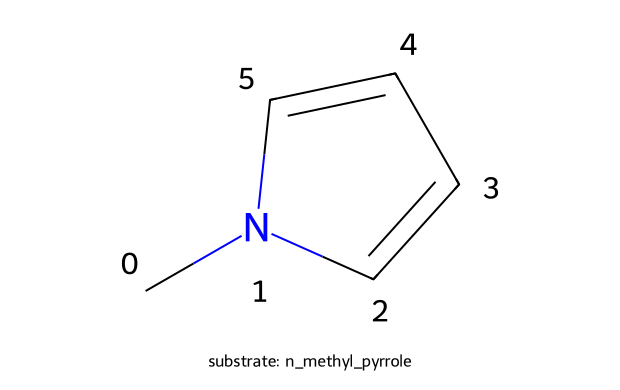

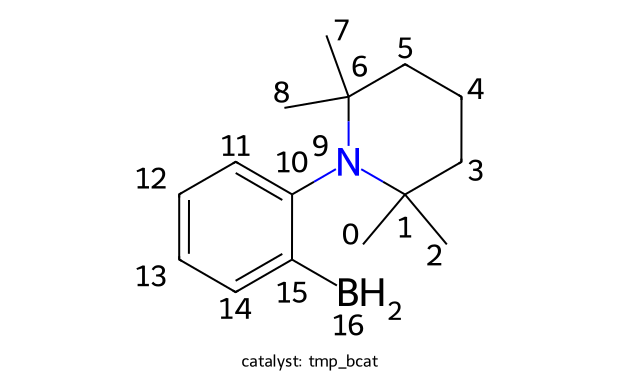

In [9]:
for _, row in screen_input.iterrows():
    draw_2d(row["smiles"], title=f"{row['role']}: {row['compound_name']}")


If you want to use an uploaded CSV in Colab instead of the inline dataframe,
run the optional cell below and replace `screen_input` with the uploaded file.
It is disabled by default so the demo remains self-contained.


In [10]:
USE_UPLOAD = False

if USE_UPLOAD and IN_COLAB:
    from google.colab import files

    uploaded = files.upload()
    csv_name = next(iter(uploaded))
    screen_input = pd.read_csv(csv_name)
    display(screen_input)
elif USE_UPLOAD:
    print("Upload mode is only available in Colab.")
else:
    print("Using the inline dataframe.")


Using the inline dataframe.


## 2. Read And Expand The Screen

`ft.screen.read(...)` normalizes the component table. `ft.screen.expand(...)`
turns substrates and catalysts into explicit systems.


In [11]:
components = ft.screen.read(screen_input)
systems = ft.screen.expand(components)

components


,role,smiles,compound_name,rpos
0,substrate,CN1C=CC=C1,n_methyl_pyrrole,2
1,catalyst,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,tmp_bcat,


In [12]:
systems[["system_name", "substrate_name", "catalyst_name", "rpos"]]


,system_name,substrate_name,catalyst_name,rpos
0,n_methyl_pyrrole__tmp_bcat,n_methyl_pyrrole,tmp_bcat,2


## 3. Create TS Guesses

Generate `TS1`-`TS4` guesses. Each TS type is returned as a separate dataframe.
For the rest of the notebook, `TS = "TS3"` is used because it includes HBpin and
is a useful demonstration of the role-based construction.


In [13]:
ts_guesses = ft.screen.create_ts_guesses(
    systems,
    ts_types=["TS1", "TS2", "TS3", "TS4"],
    n_confs=1,
)

pd.DataFrame(
    [
        {
            "ts_type": ts_type,
            "rows": len(df),
            "columns": len(df.columns),
            "example_name": df.iloc[0]["custom_name"],
        }
        for ts_type, df in ts_guesses.items()
    ]
)


,ts_type,rows,columns,example_name
0,TS1,1,21,TS1(n_methyl_pyrrole__tmp_bcat_rpos(2))
1,TS2,1,21,TS2(n_methyl_pyrrole__tmp_bcat_rpos(2))
2,TS3,1,21,TS3(n_methyl_pyrrole__tmp_bcat_rpos(2))
3,TS4,1,21,TS4(n_methyl_pyrrole__tmp_bcat_rpos(2))


In [14]:
row = ts_guesses[TS].iloc[0]
row[["custom_name", "structure_type", "system_name", "rpos", "ts_spec_id"]]


,0
custom_name,TS3(n_methyl_pyrrole__tmp_bcat_rpos(2))
structure_type,TS3
system_name,n_methyl_pyrrole__tmp_bcat
rpos,2
ts_spec_id,TS3::builtin::methylpyrrole_tmp_v1


## 4. Visualize The Generated TS Guess

The highlighted atoms are the constrained role atoms. Click labels, Ctrl-click
for distances, and Shift-click for angles in the 3D viewer.


In [15]:
show_role_rows([row], legends=[f"{TS} generated from substrate/catalyst SMILES"], columns=1)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The same system can be inspected across all four TS families.


In [16]:
all_rows = [ts_guesses[ts].iloc[0] for ts in ["TS1", "TS2", "TS3", "TS4"]]
show_role_rows(
    all_rows,
    legends=["TS1", "TS2", "TS3", "TS4"],
    columns=2,
    linked=True,
)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. Inspect Roles And Constraints

`constraint_roles` maps chemical names to atom indices in this generated row.
`constraint_spec` stores the distances and angles that `Stepper` will render
for constrained xTB/ORCA input.


In [17]:
pd.DataFrame(
    [
        {
            "role": role,
            "atom_index": int(atom_idx),
            "element": row["atoms"][int(atom_idx)],
        }
        for role, atom_idx in sorted(row["constraint_roles"].items())
    ]
)


,role,atom_index,element
0,cat_B,16,B
1,cat_H,39,H
2,cat_N,9,N
3,pin_B,56,B
4,substrate_C,42,C
5,transfer_H,67,H


In [18]:
constraint_table(row)


,kind,roles,atoms,target,measured,delta
0,distance,transfer_H-cat_B,67-16,1.376,1.382,0.006
1,distance,transfer_H-pin_B,67-56,1.264,1.265,0.001
2,distance,transfer_H-substrate_C,67-42,2.477,2.482,0.005
3,distance,cat_B-substrate_C,16-42,1.616,1.616,0.000
4,distance,pin_B-substrate_C,56-42,2.180,2.188,0.008
5,distance,pin_B-cat_B,56-16,2.007,2.015,0.008
6,angle,cat_B-transfer_H-pin_B,16-67-56,98.890,99.031,0.141
7,angle,cat_B-substrate_C-pin_B,16-42-56,61.750,61.825,0.075


The measured values above come directly from the generated coordinates. This is
the same information you can inspect manually in the 3D viewer.


## 6. Optional Live xTB Preoptimization

This section attempts a constrained xTB preoptimization only when both of these
are true:

```python
HAS_XTB is True
RUN_LIVE_XTB is True
```

In Colab, `RUN_LIVE_XTB` defaults to `True` when xTB was found. Outside Colab,
it defaults to `False` so local notebook execution can verify the fallback path
without requiring xTB.

If xTB is unavailable or the calculation fails, the notebook falls back to the
generated TS guesses and labels that dataframe clearly as not optimized.


In [22]:
RUN_LIVE_XTB = bool(IN_COLAB and HAS_XTB)
print("HAS_XTB:", HAS_XTB)
print("RUN_LIVE_XTB:", RUN_LIVE_XTB)

if RUN_LIVE_XTB:
    try:
        step = ft.Stepper(n_cores=1, save_output_dir=False)
        preopt_df = step.xtb(
            ts_guesses[TS].iloc[0:4],
            name="xtb_preopt",
            options={"gfnff": None, "opt": None},
            constraint=True,
        )
        preopt_df = ft.lowest_energy_rows(preopt_df)
        XTB_RAN = True
        print("xTB constrained preoptimization completed.")
    except Exception as exc:
        XTB_RAN = False
        print("xTB was available but the constrained run failed.")
        print("Falling back to generated TS guesses.")
        print(type(exc).__name__ + ":", exc)
        preopt_df = ts_guesses[TS].iloc[0:4].copy()
else:
    XTB_RAN = False
    print("xTB is not available or live xTB is disabled. Skipping live constrained xTB optimization.")
    preopt_df = ts_guesses[TS].iloc[0:4].copy()

print("XTB_RAN:", XTB_RAN)
preopt_df[["custom_name", "structure_type", "rpos"]].head()


No .env file found for tooltoad in TOOLTOAD_DOTENV_PATH, the current working directory, or the user home directory. Relying on pre-existing environment variables.


HAS_XTB: True
RUN_LIVE_XTB: True
xTB was available but the constrained run failed.
Falling back to generated TS guesses.
AssertionError: ORCA_EXE not found in environment variables (checked .env and system env). Please set it.
XTB_RAN: False


,custom_name,structure_type,rpos
0,TS3(n_methyl_pyrrole__tmp_bcat_rpos(2)),TS3,2


## 7. Plot The Result Or Fallback

If xTB ran, this plots the optimized/preoptimized rows. If xTB did not run, this
plots the generated TS guesses and explicitly labels the result as fallback
geometry.


In [21]:
if XTB_RAN:
    print("Plotting xTB-preoptimized structures.")
    ft.plot_mols(preopt_df, range(0, len(preopt_df)), coord_indices=slice(-1, None))
else:
    print("Fallback: plotting generated TS guesses, not xTB-optimized structures.")
    fallback_rows = [
        row
        for _, row in preopt_df.iloc[0:min(4, len(preopt_df))].iterrows()
    ]
    show_role_rows(fallback_rows, legends=None)


Fallback: plotting generated TS guesses, not xTB-optimized structures.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The fallback plot above uses the same generated guesses from `ft.screen` and
`frust.tsguess`. It is still useful for online demos because the central new
capability is structure construction and role-based constraint inspection. The
xTB step is an optional external-executable demonstration.


## 8. Minimal xTB Constraint Block

Even without running xTB, the notebook can show the exact row-level xTB
constraints FRUST would render for this row.


In [34]:
from frust.constraints import render_xtb_constraints

print(render_xtb_constraints(row))


$constrain
force constant=50
distance: 68, 17, 1.376
distance: 68, 57, 1.264
distance: 68, 43, 2.477
distance: 17, 43, 1.616
distance: 57, 43, 2.18
distance: 57, 17, 2.007
angle: 17, 68, 57, 98.89
angle: 17, 43, 57, 61.75
$end


## Summary

This Colab demo keeps the main path simple:

1. Build a small inline substrate/catalyst table.
2. Normalize and expand it with `ft.screen`.
3. Generate `TS1`-`TS4` guesses with `ft.screen.create_ts_guesses`.
4. Inspect role atoms, constraints, distances, and angles live in 2D/3D.
5. Attempt constrained xTB only if the external executable is available.

The original `d52` notebook remains the deeper local assembly manual. This
notebook is the uploadable online demo version.
